# Figure S11. Benchmarking function annotations

In [1]:
### load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

In [44]:
# map from original id to species
seqhasher = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t').unique('original_id')
uhvdb_mapping = pl.concat([
    pl.read_csv('../figure_1/uhvdb_virus_db_results/uhvdb_2026-03-26/uhvdb_mapping.tsv.gz', separator='\t'),
    pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/new_hq_hc_viruses_mapping.tsv.gz', separator='\t')
])
seqhash_reps = seqhasher.filter(pl.col('original_id').is_in(set(uhvdb_mapping['original_id']))).unique('original_id').rename({'original_id':'seqhash_rep'})
uhvdb_source_meta = pl.read_csv('../figure_1/uhvdb_final_metadata.tsv', separator='\t')
genomovar_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/genomovars_cluster/hq_hc_genomovars_info.tsv.gz', separator='\t')
uhvdb_species_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/hq_hc_species_info.tsv.gz', separator='\t')
aaicluster = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/aaicluster/hq_hc_species_aai_clusters.tsv.gz', separator='\t')

combined = (
    uhvdb_source_meta
        .join(seqhasher.unique('original_id'), left_on='seq_name', right_on='original_id', how='left')
        .join(seqhasher.with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id"))), left_on='seq_name', right_on='original_id', how='left')
        .with_columns(
            pl.when(pl.col('hash').is_not_null()).then(pl.col('hash')).otherwise(pl.col('hash_right')).alias('hash')
        )
        .join(seqhash_reps, on='hash', how='left')
        .join(uhvdb_mapping.unique('original_id'), left_on='seqhash_rep', right_on='original_id', how='left')
        .join(genomovar_info[['uhvdb_id', 'votu_rep']], left_on='new_id', right_on='uhvdb_id', how='left').rename({'votu_rep':'genomovar_rep'})
        .join(uhvdb_species_info[['uhvdb_id', 'votu_rep']], left_on='genomovar_rep', right_on='uhvdb_id', how='left')
        .join(aaicluster, left_on='votu_rep', right_on='uhvdb_id', how='left')
        .filter((pl.col('seq_name') == pl.col('seqhash_rep')) & (pl.col('new_id') == pl.col('genomovar_rep')))
        .unique('genomovar_rep')
)

In [46]:
## load uhvdb protein outputs
prot_lst = []

for file in glob.glob('../figure_1/*_results/*_outputs/function/hq_hc_genomovars_prothash.tsv.gz'):
    df = pl.read_csv(file, separator='\t')
    prot_lst.append(df)

combined_prot = (
    pl.concat(prot_lst)
        .unique('protein_id')
        .with_columns([
            pl.col('protein_id').str.replace(r"_[^_]*$", "").alias('genomovar_id')
        ])
        .filter(pl.col('genomovar_id').is_in(set(combined['genomovar_rep'])))
)

In [47]:
## load uhvdb taxonomy outputs
taxonomy_df_lst = []

for file in glob.glob('../figure_1/*_results/*_outputs/taxonomy/new_genomovars_ictv_taxonomy.tsv.gz'):
    df = pl.read_csv(file, separator='\t')
    taxonomy_df_lst.append(df)

combined_taxonomy = pl.concat(taxonomy_df_lst)

In [48]:
### identify caudoviricetes genomes
caudo_set = set(
    combined_taxonomy
        .filter(pl.col('Class') == 'Caudoviricetes')
        ['uhvdb_id']
)

In [49]:
caudo_prothash = (
    combined_prot
        .filter(pl.col('genomovar_id').is_in(caudo_set))
)

In [16]:
# Pharokka (HMM)
pharokka_df = (
    pl.read_csv('../figure_3/pharokka_hits.tsv', separator='\t')
        .filter(
            (pl.col('annot') == 'major head protein') |
            (pl.col('annot') == 'terminase large subunit') |
            (pl.col('annot') == 'portal protein')
        )
)

In [21]:
# Phold (structure)
phold_df = (
    pl.read_csv('../figure_3/phold_hits.tsv', separator='\t')
        .filter(
            (pl.col('product') == 'major head protein') |
            (pl.col('product') == 'terminase large subunit') |
            (pl.col('product') == 'portal protein')
        )
)

In [39]:
# Empathi (embedding)
empathi_df = (
    pl.read_csv('../figure_3/empathi_hits.tsv', separator='\t')
        .filter(
            (pl.col('Annotation').str.contains('major_capsid')) |
            (pl.col('Annotation').str.contains('portal')) |
            (pl.col('Annotation').str.contains('terminase'))
        )
)

In [56]:
empathi_df.group_by('Annotation').len().sort('len', descending=True)

Annotation,len
str,u32
"""DNA-associated|terminase|packa…",369268
"""pvp|capsid|major_capsid""",299420
"""pvp|portal""",231471
"""pvp|capsid|major_capsid|packag…",15734
"""pvp|capsid|major_capsid|RNA-as…",13196
…,…
"""pvp|portal|DNA-associated|pack…",1
"""DNA-associated|terminase|lysis…",1
"""pvp|capsid|major_capsid|tail|t…",1


In [70]:
caudo_prothash = (
    caudo_prothash
        .join(pharokka_df, left_on='hash', right_on='ID', how='left')
        .join(phold_df, left_on='hash', right_on='cds_id', how='left')
        .join(empathi_df, left_on='hash', right_on='', how='left')
        .filter(pl.col('annot').is_not_null() | pl.col('product').is_not_null() | pl.col('Annotation').is_not_null())
        .join(combined[['genomovar_rep', 'votu_rep']], left_on='genomovar_id', right_on='genomovar_rep', how='left')
)

In [74]:
caudo_prothash

protein_id,hash,genomovar_id,length,phrog,annot,category,phrog_right,function,product,Annotation,votu_rep
str,str,str,i64,i64,str,str,str,str,str,str,str
"""UHVDB-294169_30""","""dc7b8835f24bd1cb08028a1ab6017e…","""UHVDB-294169""",299,10,"""major head protein""","""head and packaging""",null,null,null,"""pvp|capsid|major_capsid""","""UHVDB-527752"""
"""UHVDB-75645_78""","""ff277b0890f3b9869f80795c77afb7…","""UHVDB-75645""",844,6547,"""portal protein""","""head and packaging""",null,null,null,"""pvp|portal""","""UHVDB-230862"""
"""UHVDB-533590_11""","""f0f96e6a299c9c424cec8623285346…","""UHVDB-533590""",640,2662,"""portal protein""","""head and packaging""",null,null,null,"""pvp|portal""","""UHVDB-533590"""
"""UHVDB-201600_44""","""5ed9ce9ab56c9309ad8bc259fd99d2…","""UHVDB-201600""",324,10,"""major head protein""","""head and packaging""",null,null,null,"""pvp|capsid|major_capsid""","""UHVDB-201600"""
"""UHVDB-26742_21""","""15356aa7daa4813c57a8d6bccf0fd7…","""UHVDB-26742""",638,156,"""portal protein""","""head and packaging""",null,null,null,"""pvp|portal""","""UHVDB-231936"""
…,…,…,…,…,…,…,…,…,…,…,…
"""UHVDB-175049_20""","""fcc1a43322c2373fa2d86dbae59829…","""UHVDB-175049""",385,12,"""portal protein""","""head and packaging""",null,null,null,"""pvp|portal""","""UHVDB-319363"""
"""UHVDB-158845_35""","""a4eecf9794a864848a698782ee5b23…","""UHVDB-158845""",null,null,null,null,null,null,null,"""pvp|portal""","""UHVDB-274680"""
"""UHVDB-306066_34""","""f105ae7671080a28413e7a2652c67f…","""UHVDB-306066""",null,null,null,null,null,null,null,"""DNA-associated|terminase|packa…","""UHVDB-504912"""


In [96]:
hallmark_queries = {
    'annot': ['major head protein', 'terminase large subunit', 'portal protein'],
    'product': ['major head protein', 'terminase large subunit', 'portal protein'],
    'Annotation': ['pvp|capsid|major_capsid', 'pvp|portal', 'DNA-associated|terminase|packaging_assembly'],
}

single_copy_counts = []

for column, hallmarks in hallmark_queries.items():
    for hallmark in hallmarks:
        n_genomovars = (
            caudo_prothash
                .filter(pl.col(column).is_not_null() & (pl.col(column) == hallmark))
                .group_by('genomovar_id')
                .len()
                .filter(pl.col('len') == 1)
                .height
        )

        single_copy_counts.append({
            'column': column,
            'hallmark': hallmark,
            'n_genomovars_single_copy': n_genomovars,
        })

single_copy_counts = pl.DataFrame(single_copy_counts)
single_copy_counts

column,hallmark,n_genomovars_single_copy
str,str,i64
"""annot""","""major head protein""",353637
"""annot""","""terminase large subunit""",377275
"""annot""","""portal protein""",370945
"""product""","""major head protein""",15869
"""product""","""terminase large subunit""",16040
"""product""","""portal protein""",12636
"""Annotation""","""pvp|capsid|major_capsid""",355966
"""Annotation""","""pvp|portal""",375946
"""Annotation""","""DNA-associated|terminase|packa…",122813


In [123]:
hallmark_queries = {
    'annot': ['major head protein', 'terminase large subunit', 'portal protein'],
    'product': ['major head protein', 'terminase large subunit', 'portal protein'],
    'Annotation': ['pvp|capsid|major_capsid', 'pvp|portal', 'DNA-associated|terminase|packaging_assembly'],
}

single_copy_counts = []
single_copy_mcps = set()
single_copy_terls = set()
single_copy_portals = set()

for column, hallmarks in hallmark_queries.items():
    for hallmark in hallmarks:
        if 'major' in hallmark:
            n_genomovars = set(
                caudo_prothash
                    .filter(~pl.col('genomovar_id').is_in(single_copy_mcps))
                    .filter(pl.col(column).is_not_null() & (pl.col(column) == hallmark))
                    .group_by('genomovar_id')
                    .len()
                    .filter(pl.col('len') == 1)
                    ['genomovar_id']
            )
            single_copy_mcps.update(n_genomovars)
        elif 'terminase' in hallmark:
            n_genomovars = set(
                caudo_prothash
                    .filter(~pl.col('genomovar_id').is_in(single_copy_terls))
                    .filter(pl.col(column).is_not_null() & (pl.col(column) == hallmark))
                    .group_by('genomovar_id')
                    .len()
                    .filter(pl.col('len') == 1)
                    ['genomovar_id']
            )
            single_copy_terls.update(n_genomovars)
        elif 'portal' in hallmark:
            n_genomovars = set(
                caudo_prothash
                    .filter(~pl.col('genomovar_id').is_in(single_copy_portals))
                    .filter(pl.col(column).is_not_null() & (pl.col(column) == hallmark))
                    .group_by('genomovar_id')
                    .len()
                    .filter(pl.col('len') == 1)
                    ['genomovar_id']
            )
            single_copy_portals.update(n_genomovars)

        single_copy_counts.append({
            'column': column,
            'hallmark': hallmark,
            'n_genomovars_single_copy': len(n_genomovars),
        })

single_copy_counts = pl.DataFrame(single_copy_counts)
single_copy_counts

column,hallmark,n_genomovars_single_copy
str,str,i64
"""annot""","""major head protein""",353637
"""annot""","""terminase large subunit""",377275
"""annot""","""portal protein""",370945
"""product""","""major head protein""",11111
"""product""","""terminase large subunit""",11787
"""product""","""portal protein""",9049
"""Annotation""","""pvp|capsid|major_capsid""",54680
"""Annotation""","""pvp|portal""",16240
"""Annotation""","""DNA-associated|terminase|packa…",40367


In [131]:
votu_agg = (
    caudo_prothash
        [['genomovar_id']]
        .with_columns(pl.when(pl.col('genomovar_id').is_in(single_copy_mcps)).then(1).otherwise(0).alias('is_single_copy_mcp'))
        .with_columns(pl.when(pl.col('genomovar_id').is_in(single_copy_terls)).then(1).otherwise(0).alias('is_single_copy_terl'))
        .with_columns(pl.when(pl.col('genomovar_id').is_in(single_copy_portals)).then(1).otherwise(0).alias('is_single_copy_portal'))
        .group_by('genomovar_id')
        .agg([
            (pl.max('is_single_copy_mcp') + pl.max('is_single_copy_terl') + pl.max('is_single_copy_portal')).alias('n_single_copy_hallmarks'),
        ])
)
print("Total number of genomovars:", votu_agg.height)
print("Prop. of genomovars with 3 hallmarks:", votu_agg.filter(pl.col('n_single_copy_hallmarks') == 3).height / votu_agg.height)
print("Number of genomovars with 2 hallmarks:", votu_agg.filter(pl.col('n_single_copy_hallmarks') >= 2).height)
print("Prop. of genomovars with 2 hallmarks:", votu_agg.filter(pl.col('n_single_copy_hallmarks') >= 2).height / votu_agg.height)
print("Prop. of genomovars with 1 hallmark:", votu_agg.filter(pl.col('n_single_copy_hallmarks') >= 1).height / votu_agg.height)
print("Prop. of genomovars with 0 hallmarks:", votu_agg.filter(pl.col('n_single_copy_hallmarks') == 0).height / votu_agg.height)

Total number of genomovars: 466197
Prop. of genomovars with 3 hallmarks: 0.7216391353869716
Number of genomovars with 2 hallmarks: 444847
Prop. of genomovars with 2 hallmarks: 0.9542039095060671
Prop. of genomovars with 1 hallmark: 0.9948970070592474
Prop. of genomovars with 0 hallmarks: 0.005102992940752515


In [129]:
votu_agg = (
    caudo_prothash
        [['genomovar_id', 'votu_rep']]
        .with_columns(pl.when(pl.col('genomovar_id').is_in(single_copy_mcps)).then(1).otherwise(0).alias('is_single_copy_mcp'))
        .with_columns(pl.when(pl.col('genomovar_id').is_in(single_copy_terls)).then(1).otherwise(0).alias('is_single_copy_terl'))
        .with_columns(pl.when(pl.col('genomovar_id').is_in(single_copy_portals)).then(1).otherwise(0).alias('is_single_copy_portal'))
        .group_by('votu_rep')
        .agg([
            (pl.max('is_single_copy_mcp') + pl.max('is_single_copy_terl') + pl.max('is_single_copy_portal')).alias('n_single_copy_hallmarks'),
        ])
)
print("Total number of species:", votu_agg.height)
print("Prop. of species with 3 hallmarks:", votu_agg.filter(pl.col('n_single_copy_hallmarks') == 3).height / votu_agg.height)
print("Prop. of species with 2 hallmarks:", votu_agg.filter(pl.col('n_single_copy_hallmarks') >= 2).height / votu_agg.height)
print("Prop. of species with 1 hallmark:", votu_agg.filter(pl.col('n_single_copy_hallmarks') >= 1).height / votu_agg.height)
print("Prop. of species with 0 hallmarks:", votu_agg.filter(pl.col('n_single_copy_hallmarks') == 0).height / votu_agg.height)

Total number of species: 174350
Prop. of species with 3 hallmarks: 0.7164381990249498
Prop. of species with 2 hallmarks: 0.9537998279323201
Prop. of species with 1 hallmark: 0.9942070547748781
Prop. of species with 0 hallmarks: 0.005792945225121881


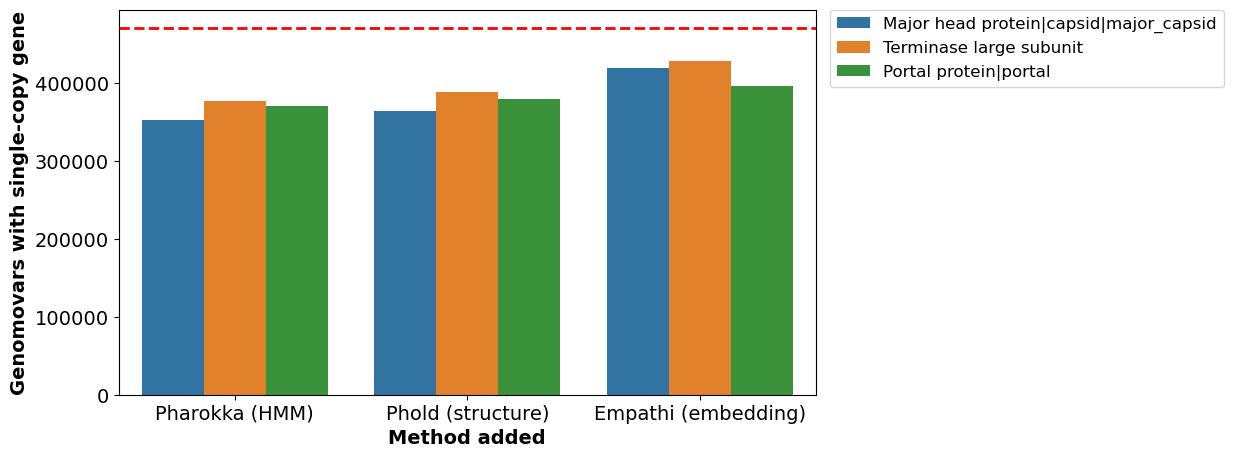

Hallmark,step,method_added,method_label,n_genomovars_single_copy_cumulative
str,i64,str,str,i64
"""Major head protein|capsid|majo…",1,"""annot""","""Pharokka (HMM)""",353637
"""Major head protein|capsid|majo…",2,"""product""","""Phold (structure)""",364748
"""Major head protein|capsid|majo…",3,"""Annotation""","""Empathi (embedding)""",419428
"""Terminase large subunit""",1,"""annot""","""Pharokka (HMM)""",377275
"""Terminase large subunit""",2,"""product""","""Phold (structure)""",389062
"""Terminase large subunit""",3,"""Annotation""","""Empathi (embedding)""",429429
"""Portal protein|portal""",1,"""annot""","""Pharokka (HMM)""",370945
"""Portal protein|portal""",2,"""product""","""Phold (structure)""",379994
"""Portal protein|portal""",3,"""Annotation""","""Empathi (embedding)""",396234


In [151]:
plt.rcParams.update({'font.size': 14})

# Cumulative number of genomovar_ids with single-copy hallmarks as methods are added
method_order = ['annot', 'product', 'Annotation']
method_label_map = {
    'annot': 'Pharokka (HMM)',
    'product': 'Phold (structure)',
    'Annotation': 'Empathi (embedding)',
}

hallmark_method_filters = {
    'major head protein / pvp|capsid|major_capsid': {
        'annot': pl.col('annot') == 'major head protein',
        'product': pl.col('product') == 'major head protein',
        'Annotation': pl.col('Annotation') == 'pvp|capsid|major_capsid',
    },
    'terminase large subunit': {
        'annot': pl.col('annot') == 'terminase large subunit',
        'product': pl.col('product') == 'terminase large subunit',
        'Annotation': pl.col('Annotation') == 'DNA-associated|terminase|packaging_assembly',
    },
    'portal protein / pvp|portal': {
        'annot': pl.col('annot') == 'portal protein',
        'product': pl.col('product') == 'portal protein',
        'Annotation': pl.col('Annotation') == 'pvp|portal',
    },
}

cumulative_rows = []

for hallmark_label, per_method_filter in hallmark_method_filters.items():
    cumulative_ids = set()
    for i, method in enumerate(method_order, start=1):
        method_ids = set(
            caudo_prothash
                .filter(per_method_filter[method])
                .group_by('genomovar_id')
                .len()
                .filter(pl.col('len') == 1)
                ['genomovar_id']
        )
        cumulative_ids.update(method_ids)

        cumulative_rows.append({
            'Hallmark': hallmark_label,
            'step': i,
            'method_added': method,
            'method_label': method_label_map[method],
            'n_genomovars_single_copy_cumulative': len(cumulative_ids),
        })

cumulative_single_copy = (
    pl.DataFrame(cumulative_rows)
        .with_columns([
            pl.col('Hallmark').str.replace('major head protein / pvp|capsid|major_capsid', 'Major head protein')
                .str.replace('portal protein / pvp|portal', 'Portal protein')
                .str.replace('terminase large subunit', 'Terminase large subunit').alias('Hallmark'),
        ])
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=cumulative_single_copy,
    x='method_label',
    y='n_genomovars_single_copy_cumulative',
    hue='Hallmark'
)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0, fontsize=12)
plt.xlabel('Method added', fontdict={'fontweight': 'bold'})
plt.ylabel('Genomovars with single-copy gene', fontdict={'fontweight': 'bold'})
plt.axhline(y=471238, color='r', linestyle='--', linewidth=2)
plt.show()
# add horizontal line at 471,238

cumulative_single_copy

Category,n_genomovars
str,i64
"""0""",2379
""">=1""",463818
""">=2""",444847
"""3""",336426


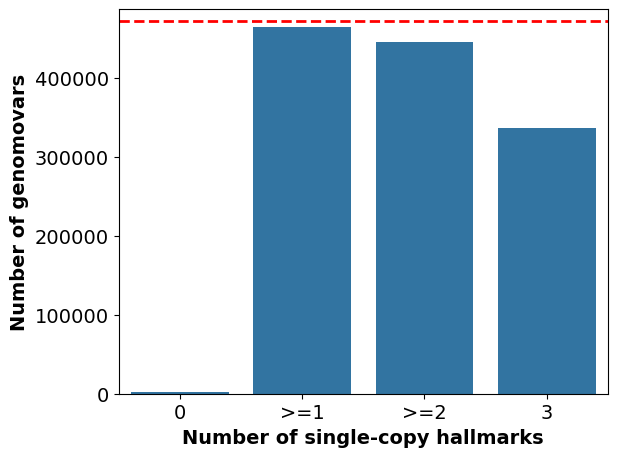

: 

In [ ]:
# Bar chart: number of genomovars with 0, >=1, >=2, and 3 single-copy hallmarks
genomovar_hallmark_counts = (
    caudo_prothash
        .select('genomovar_id')
        .unique()
        .with_columns([
            pl.col('genomovar_id').is_in(single_copy_mcps).cast(pl.Int8).alias('is_single_copy_mcp'),
            pl.col('genomovar_id').is_in(single_copy_terls).cast(pl.Int8).alias('is_single_copy_terl'),
            pl.col('genomovar_id').is_in(single_copy_portals).cast(pl.Int8).alias('is_single_copy_portal'),
        ])
        .with_columns([
            (pl.col('is_single_copy_mcp') + pl.col('is_single_copy_terl') + pl.col('is_single_copy_portal')).alias('n_single_copy_hallmarks')
        ])
)

hallmark_bin_counts = pl.DataFrame({
    'Category': ['0', '>=1', '>=2', '3'],
    'n_genomovars': [
        genomovar_hallmark_counts.filter(pl.col('n_single_copy_hallmarks') == 0).height,
        genomovar_hallmark_counts.filter(pl.col('n_single_copy_hallmarks') >= 1).height,
        genomovar_hallmark_counts.filter(pl.col('n_single_copy_hallmarks') >= 2).height,
        genomovar_hallmark_counts.filter(pl.col('n_single_copy_hallmarks') == 3).height,
    ]
})

# plt.figure(figsize=(6, 5))
sns.barplot(data=hallmark_bin_counts.to_pandas(), x='Category', y='n_genomovars')
plt.xlabel('Number of single-copy hallmarks', fontdict={'fontweight': 'bold'})
plt.ylabel('Number of genomovars', fontdict={'fontweight': 'bold'})
plt.axhline(y=471238, color='r', linestyle='--', linewidth=2)
plt.tight_layout()

hallmark_bin_counts